In [1]:
from warnings import filterwarnings
import random

import torch.cuda as cuda

import sys
sys.path.append('../')

from scformer.model import *
from scformer.utils import *

filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ["PYTHONHASHSEED"] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
adata = sc.read_h5ad('../output/pbmc_benchmark_data/pbmc_benchmark_s1d1.h5ad')
adata

AnnData object with n_obs × n_vars = 5227 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'Annotation'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [3]:
node_ids = np.load('../output/pbmc_benchmark_data/Node_Ids.npy')
cell_emb = np.load('../output/pbmc_benchmark_data/cell_embedding.npy')
cell_emb_ = pd.DataFrame(cell_emb, index=node_ids)
cell_emb_sorted = cell_emb_.sort_index()
adata.obsm["cell_emb"] = cell_emb_sorted.values
adata

AnnData object with n_obs × n_vars = 5227 × 14087
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'Annotation'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap', 'cell_emb'
    layers: 'counts'

In [4]:
pred = np.load('../output/pbmc_benchmark_data/pred.npy')
pred_ = pd.DataFrame(pred, index=node_ids)
pred_sorted = pred_.sort_index()
adata.obs['pre'] = pred_sorted.values
adata.obs['pre'] = adata.obs['pre'].astype('category')

In [5]:
adata.var_names_make_unique()
# sc.pp.log1p(adata_subset)
sc.pp.neighbors(adata, use_rep="cell_emb")
sc.tl.umap(adata, random_state=seed)

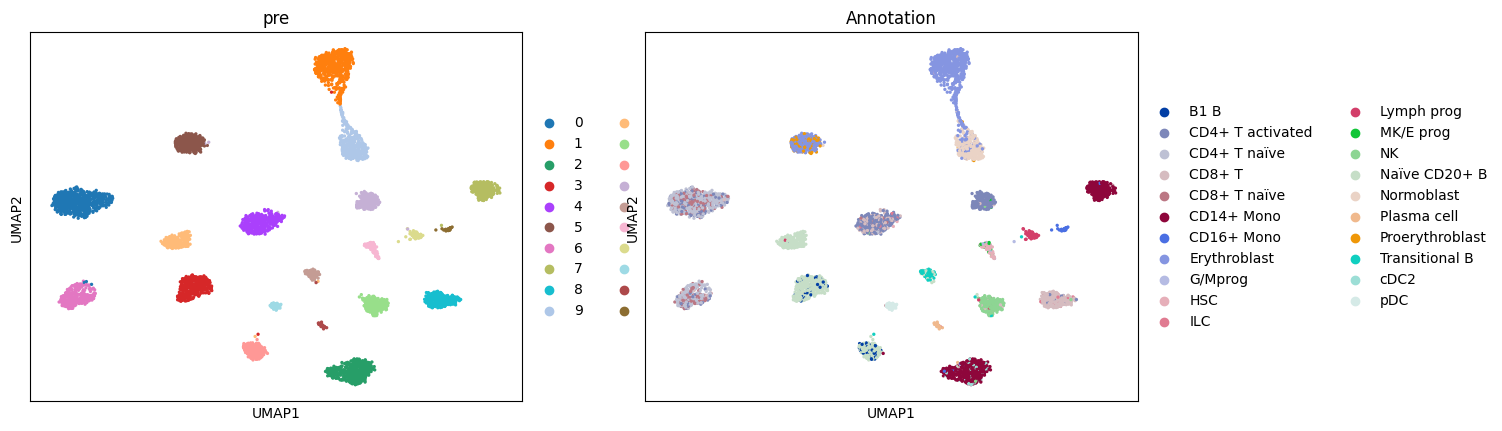

In [6]:
sc.pl.umap(adata, color=['pre', 'Annotation'], show=True)

TypeError: The numpy boolean negative, the `-` operator, is not supported, use the `~` operator or the logical_not function instead.

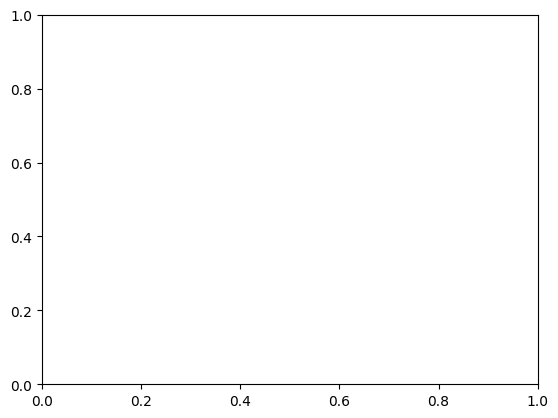

In [7]:
# Naïve CD20+ B CD4+ T activated
# 创建一个新的标注列
adata.obs['Target_Cell'] = adata.obs['Annotation'].isin(['Naïve CD20+ B'])
sc.pl.umap(adata, color=['Target_Cell'], show=True)

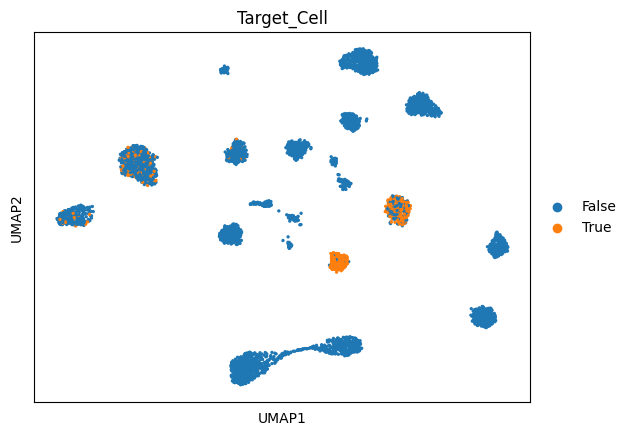

In [8]:
adata.obs['Target_Cell'] = adata.obs['Annotation'].isin(['CD4+ T activated'])
sc.pl.umap(adata, color=['Target_Cell'], show=True)

Annotations in target clusters: ['HSC', 'CD4+ T activated', 'CD8+ T', 'CD8+ T naïve', 'ILC', 'CD4+ T naïve', 'Erythroblast', 'NK', 'MK/E prog', 'Lymph prog']
Categories (10, object): ['CD4+ T activated', 'CD4+ T naïve', 'CD8+ T', 'CD8+ T naïve', ..., 'ILC', 'Lymph prog', 'MK/E prog', 'NK']
Clusters [4, 13] confirmed to correspond to CD4+ T activated. Proceeding with analysis.


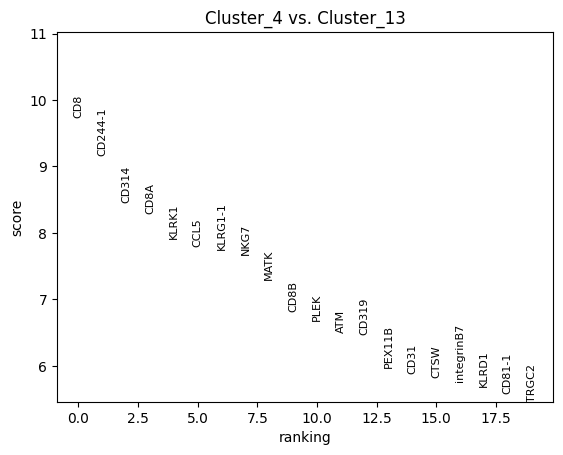

Differential gene analysis results saved to 'differential_genes_cluster_4_vs_13.csv'.


In [10]:
# 确认目标簇是否对应目标细胞类型
target_clusters = [4, 13]
target_annotation = 'CD4+ T activated'

# 检查目标簇的细胞类型
subset = adata[adata.obs['pre'].isin(target_clusters)]
print("Annotations in target clusters:", subset.obs['Annotation'].unique())

# 如果目标簇对应正确的细胞类型，继续分析
if target_annotation in subset.obs['Annotation'].unique():
    print(f"Clusters {target_clusters} confirmed to correspond to {target_annotation}. Proceeding with analysis.")
    
    # 添加分组标签
    adata.obs['Cluster'] = adata.obs['pre'].apply(
        lambda x: f"Cluster_{x}" if x in target_clusters else 'Other'
    )

    # 差异表达分析：Cluster_4 vs Cluster_13
    sc.tl.rank_genes_groups(adata, groupby='Cluster', reference='Cluster_13', groups=['Cluster_4'])

    # 可视化差异表达基因
    sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

    # 导出差异基因结果
    de_genes = adata.uns['rank_genes_groups']
    de_genes_df = pd.DataFrame({
        'Gene': de_genes['names']['Cluster_4'],
        'LogFC': de_genes['logfoldchanges']['Cluster_4'],
        'pvals': de_genes['pvals']['Cluster_4'],
        'adj_pvals': de_genes['pvals_adj']['Cluster_4']
    })
    
    # 保存到文件
    # de_genes_df.to_csv('differential_genes_cluster_4_vs_13.csv', index=False)
    print("Differential gene analysis results saved to 'differential_genes_cluster_4_vs_13.csv'.")

else:
    print(f"Clusters {target_clusters} do not correspond to {target_annotation}. Please check the data.")


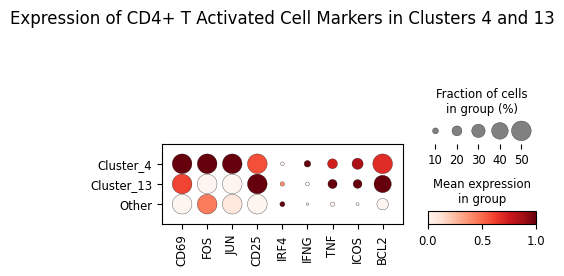

In [9]:
import scanpy as sc

# 确保目标簇已标注
target_clusters = [4, 13]
adata.obs['Cluster'] = adata.obs['pre'].apply(
    lambda x: f"Cluster_{x}" if x in target_clusters else 'Other'
)

# 定义 Marker 基因列表
markers = [# 早期激活标志基因
    "CD69", "FOS", "JUN",
    
    # 中期激活标志基因
    "CD25", "CD40L", "IRF4", "IFNG", "TNF",
    
    # 晚期激活标志基因
    "CTLA-4", "PD-1", "ICOS", "BCL2"]

# 确保基因在数据集中
available_markers = [gene for gene in markers if gene in adata.var_names]
missing_markers = set(markers) - set(available_markers)

if missing_markers:
    print(f"Warning: The following marker genes are not found in the dataset: {missing_markers}")

# 绘制 Dot Plot
sc.pl.dotplot(
    adata,
    var_names=available_markers,
    groupby='Cluster',
    dot_max=0.5,  # 可调整点的大小比例
    standard_scale='var',  # 基因标准化显示
    title="Expression of CD4+ T Activated Cell Markers in Clusters 4 and 13",
    save=True
)


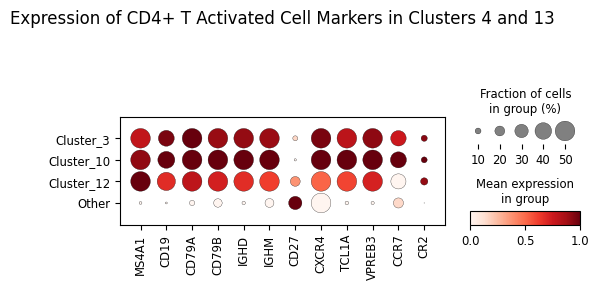

In [10]:
import scanpy as sc

# 确保目标簇已标注
target_clusters = [3, 10, 12]
adata.obs['Cluster'] = adata.obs['pre'].apply(
    lambda x: f"Cluster_{x}" if x in target_clusters else 'Other'
)

# 定义 Marker 基因列表
markers = [
    # B细胞核心标志
    "MS4A1",  # CD20
    "CD19",  # 泛B细胞标志
    "CD79A",  # BCR复合物
    "CD79B",  # BCR复合物

    # Naïve B细胞标志
    "IGHD",  # IgD高表达
    "IGHM",  # IgM高表达
    "CD27",  # Naïve B细胞CD27低表达
    "CXCR4",  # 趋化因子受体，Naïve B细胞中高表达

    # 其他Naïve状态相关
    "TCL1A",  # 调控B细胞成熟和活化
    "VPREB3",  # 与B细胞分化相关
    "CCR7",  # 向淋巴结迁移的趋化因子受体
    "CR2"  # CD21，与补体系统相关
]

# 确保基因在数据集中
available_markers = [gene for gene in markers if gene in adata.var_names]
missing_markers = set(markers) - set(available_markers)

if missing_markers:
    print(f"Warning: The following marker genes are not found in the dataset: {missing_markers}")

# 绘制 Dot Plot
sc.pl.dotplot(
    adata,
    var_names=available_markers,
    groupby='Cluster',
    dot_max=0.5,  # 可调整点的大小比例
    standard_scale='var',  # 基因标准化显示
    title="Expression of CD4+ T Activated Cell Markers in Clusters 4 and 13",
    save=True
)


Top 5 differentially expressed genes in Cluster_3: ['CD19-1', 'CD22-1', 'CD21', 'CD268', 'CD40-1']
Top 5 differentially expressed genes in Cluster_10: ['CD72-1', 'CD19-1', 'CD22-1', 'CD20', 'CD268']
Top 5 differentially expressed genes in Cluster_12: ['CD19-1', 'CD45RA', 'CD22-1', 'CD20', 'CD268']


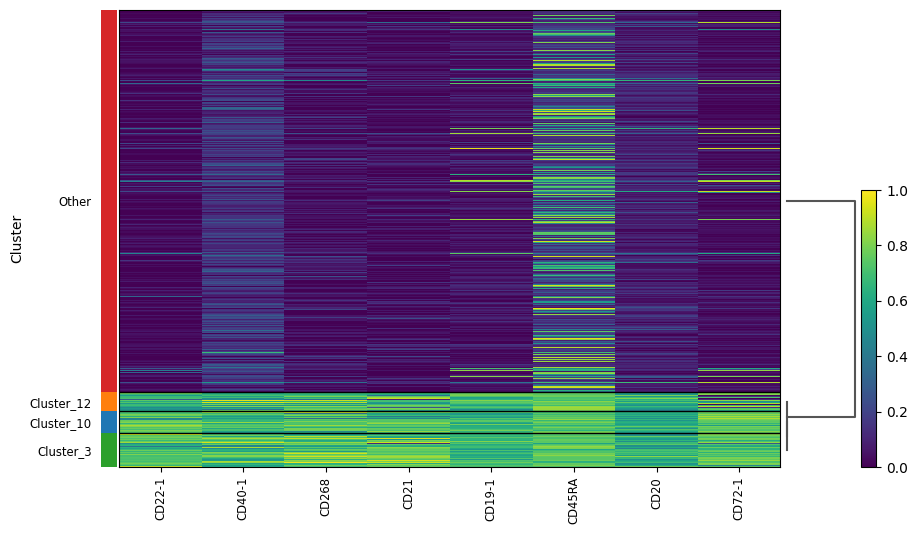

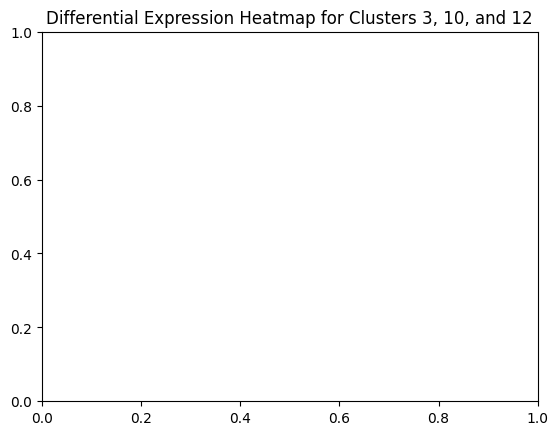

In [11]:
import scanpy as sc
import matplotlib.pyplot as plt

# 确保目标簇已正确标注
target_clusters = [3, 10, 12]
adata.obs['Cluster'] = adata.obs['pre'].apply(
    lambda x: f"Cluster_{x}" if x in target_clusters else 'Other'
)
adata.obs['Cluster'] = adata.obs['Cluster'].astype('category')  # 转为类别型数据

# 差异表达分析
sc.tl.rank_genes_groups(
    adata,
    groupby='Cluster',  # 使用新标注的 Cluster 分组
    groups=['Cluster_3', 'Cluster_10', 'Cluster_12'],  # 指定目标簇
    reference='Other',  # 非目标簇作为参考
    method='t-test'  # 差异分析方法
)

# 提取每个簇的差异表达基因（前五个）
top_genes = {}
for cluster in ['Cluster_3', 'Cluster_10', 'Cluster_12']:
    if cluster in adata.uns['rank_genes_groups']['names'].dtype.names:
        # 提取前五个基因，并将 NumPy 数组转换为 Python 列表
        top_genes[cluster] = list(adata.uns['rank_genes_groups']['names'][cluster][:5])
    else:
        print(f"Warning: No genes found for {cluster}")
        top_genes[cluster] = []

# 打印差异表达基因
for cluster, genes in top_genes.items():
    if len(genes) > 0:  # 检查是否为空
        print(f"Top 5 differentially expressed genes in {cluster}: {genes}")
    else:
        print(f"No differentially expressed genes found for {cluster}")

# 确保差异基因存在，准备绘制热图
all_top_genes = list(set(sum(top_genes.values(), [])))
if len(all_top_genes) > 0:
    # 绘制热图
    sc.pl.heatmap(
        adata,
        var_names=all_top_genes,
        groupby='Cluster',
        cmap='viridis',  # 热图颜色方案
        dendrogram=True,  # 是否绘制树状图
        standard_scale='var',  # 按基因标准化
        figsize=(10, 6)  # 设置热图大小
    )
    # 设置标题
    plt.title("Differential Expression Heatmap for Clusters 3, 10, and 12")
    plt.show()
else:
    print("No genes available for heatmap plotting.")



Top 5 differentially expressed genes in Cluster_3:
     gene  logfoldchanges         pvals
0    IGKC       84.406982  1.441168e-12
1   RPS27       19.294588  8.023860e-13
2  MT-ND3       15.164336  1.572925e-09
3   RPL30        8.769092  1.744453e-09
4  MT-CYB       11.878627  5.393500e-09

Top 5 differentially expressed genes in Cluster_10:
     gene  logfoldchanges         pvals
0   IGLC2       45.177975  1.548036e-40
1   IGLC3       20.195944  7.122452e-20
2  CD72-1        0.598913  2.139415e-16
3     IgD        0.748571  1.383629e-13
4    IGHM        7.514045  6.463764e-08

Top 5 differentially expressed genes in Cluster_12:
     gene  logfoldchanges         pvals
0  CD58-1        0.442506  1.100404e-11
1    CD95        0.851956  1.325694e-10
2    CD54        0.568163  1.762942e-10
3  CD82-1        0.692293  1.258029e-09
4   AHNAK        1.835498  6.751778e-09


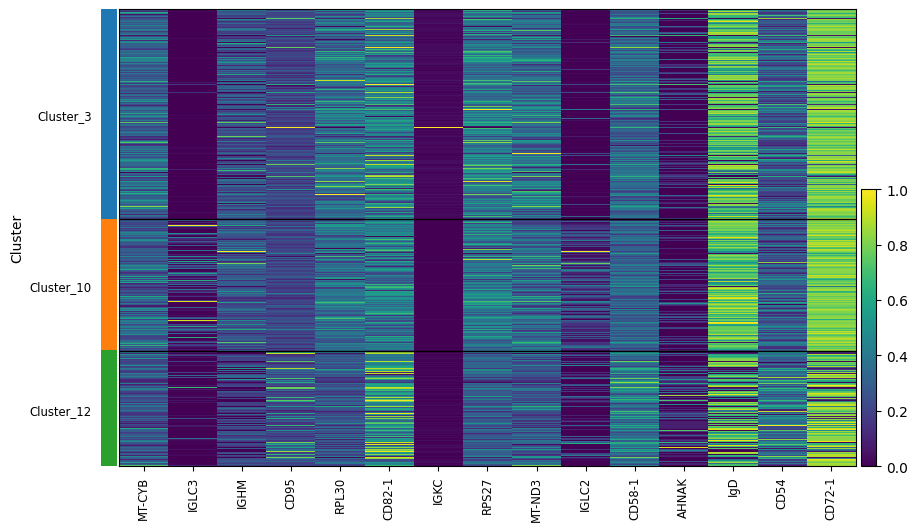

In [12]:
import scanpy as sc
import pandas as pd

# 只关注目标簇：3、10 和 12
adata_filtered = adata[adata.obs['pre'].isin([3, 10, 12])].copy()
adata_filtered.obs['Cluster'] = adata_filtered.obs['pre'].apply(
    lambda x: f"Cluster_{x}"
)
adata_filtered.obs['Cluster'] = adata_filtered.obs['Cluster'].astype('category')

# 针对三个簇进行差异表达分析
sc.tl.rank_genes_groups(
    adata_filtered,
    groupby='Cluster',  # 分组变量
    method='t-test',  # 差异分析方法
    reference='rest'  # 将其余簇作为参考
)

# 提取每个簇的显著差异基因
top_genes_per_cluster = {}
for cluster in ['Cluster_3', 'Cluster_10', 'Cluster_12']:
    # 提取每个簇的前 5 个差异基因
    cluster_genes = pd.DataFrame({
        'gene': adata_filtered.uns['rank_genes_groups']['names'][cluster],
        'logfoldchanges': adata_filtered.uns['rank_genes_groups']['logfoldchanges'][cluster],
        'pvals': adata_filtered.uns['rank_genes_groups']['pvals'][cluster]
    }).head(5)
    top_genes_per_cluster[cluster] = cluster_genes

# 打印结果
for cluster, genes in top_genes_per_cluster.items():
    print(f"\nTop 5 differentially expressed genes in {cluster}:")
    print(genes)

# 可视化差异基因的表达模式
all_top_genes = list(set(sum([list(df['gene']) for df in top_genes_per_cluster.values()], [])))

sc.pl.heatmap(
    adata_filtered,
    var_names=all_top_genes,
    groupby='Cluster',
    cmap='viridis',
    standard_scale='var',
    figsize=(10, 6)
)


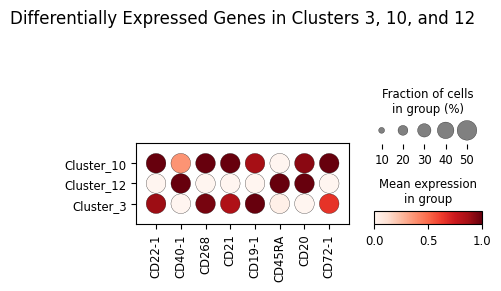

In [13]:
# 只保留目标簇：3、10 和 12
adata = adata[adata.obs['pre'].isin([3, 10, 12])].copy()

# 差异表达分析（原有代码无须修改）

# 补充热图展示的目标差异基因（所有目标簇前 5 的基因合并）
all_top_genes = list(set(sum(top_genes.values(), [])))

# 使用已有的 DotPlot 方法展示
sc.pl.dotplot(
    adata,
    var_names=all_top_genes,
    groupby='Cluster',
    dot_max=0.5,
    standard_scale='var',  # 基因标准化显示
    title="Differentially Expressed Genes in Clusters 3, 10, and 12",
    save=True
)


KeyError: 'Could not find key pre_rare_below_5 in .var_names or .obs.columns.'

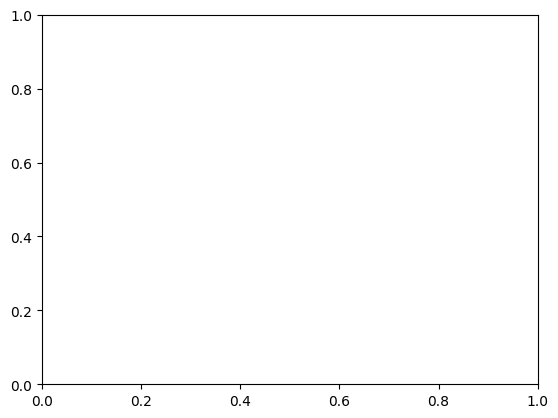

In [7]:
# sc.pl.umap(adata, color=['pre_rare_below_5'], save=True)
# color=['true_rare_below_5', 'pre_rare_below_5'],

In [7]:
FiRE_results = pd.read_csv('../benchmark/results/s1d1/FiRE_rare_cells_status_fire.csv')
adata.obs['fire'] = FiRE_results['Status'].tolist()
adata.obs['fire'] 

GCATTAGCATAAGCGG-1-s1d1    non-rare
TACAGGTGTTAGAGTA-1-s1d1    non-rare
AGGATCTAGGTCTACT-1-s1d1    non-rare
GTAGAAAGTGACACAG-1-s1d1    non-rare
TCCGAAAAGGATCATA-1-s1d1    non-rare
                             ...   
GTCGAATAGTTTCGGT-1-s1d1    non-rare
AGTAGTCTCTGGGCGT-1-s1d1    non-rare
GCCCGAAGTATGGAGC-1-s1d1    non-rare
CTACATTAGCGCGTTC-1-s1d1    non-rare
GATTCTTTCACCCATC-1-s1d1    non-rare
Name: fire, Length: 5227, dtype: object

In [8]:
GapClust_results = pd.read_csv('../benchmark/results/s1d1/GapClust_rare_cells_status.csv')
adata.obs['gapclust'] = GapClust_results['Status'].tolist()

In [9]:
GiniClust3_results = pd.read_csv('../benchmark/results/s1d1/GiniClust3_rare_cells_indices.csv')
adata.obs['giniclust3'] = GiniClust3_results['rare_cells'].tolist()

In [10]:
RaceID_results = pd.read_csv('../benchmark/results/s1d1/RaceID3_rare_cells_status.csv')
adata.obs['raceid3'] = RaceID_results['Status'].tolist()

In [11]:
CellSIUS_results = pd.read_csv('../benchmark/results/s1d1/rare_cells_status_cellsius.csv')
adata.obs['cellsius'] = CellSIUS_results['Status'].tolist()

In [12]:
SCMER_results = pd.read_csv('../benchmark/results/s1d1/SCMER_rare_cells_indices.csv')
adata.obs['scmer'] = SCMER_results['rare_cells'].tolist()

In [13]:
scCAD_results = pd.read_csv('../benchmark/results/s1d1/scCAD_rare_cells_indices.csv')
adata.obs['sccad'] = scCAD_results['rare_cells'].tolist()

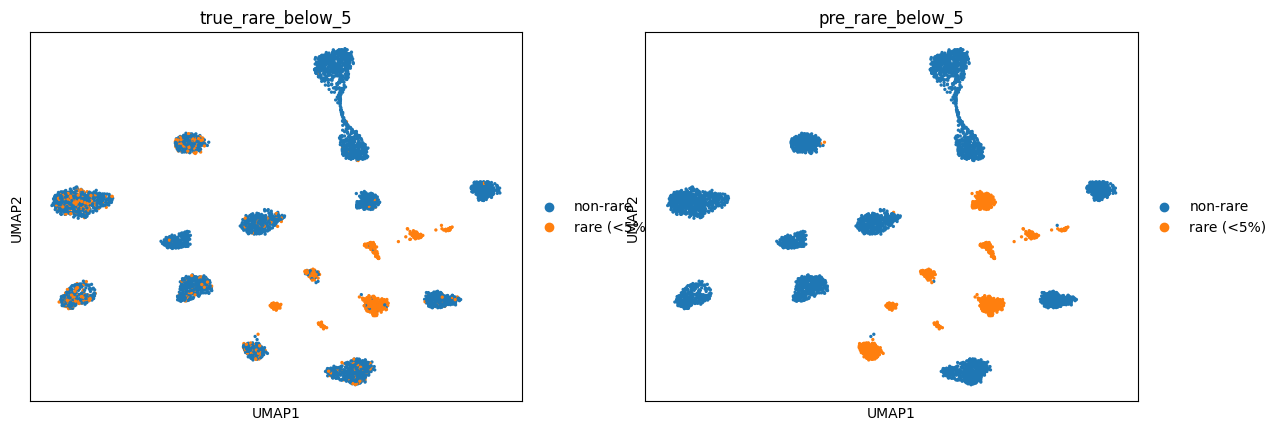

In [14]:
# 获取真实标签中小于 5% 的稀有细胞类型
cell_types = adata.obs['Annotation']
cell_type_counts = cell_types.value_counts()
cell_type_proportions = cell_type_counts / cell_type_counts.sum()

# 定义小于5%的稀有细胞类型
target_cell_types_below_5 = cell_type_proportions[cell_type_proportions < 0.05].index.tolist()

# 标记真实标签中小于5%的细胞
adata.obs['true_rare_below_5'] = adata.obs['Annotation'].apply(
    lambda x: 'rare (<5%)' if x in target_cell_types_below_5 else 'non-rare'
)

# 映射 `pre` 的结果
pre_labels = adata.obs['pre']
cluster_counts = pre_labels.value_counts(normalize=True)

# 定义小于5%的稀有簇
rare_clusters_below_5 = cluster_counts[cluster_counts < 0.045].index.tolist()

# 映射到 `rare` 和 `non-rare`
adata.obs['pre_rare_below_5'] = adata.obs['pre'].apply(
    lambda x: 'rare (<5%)' if x in rare_clusters_below_5 else 'non-rare'
)

# 绘制真实标签和 `pre` 的预测结果
sc.pl.umap(adata, color=['true_rare_below_5', 'pre_rare_below_5'], show=True)


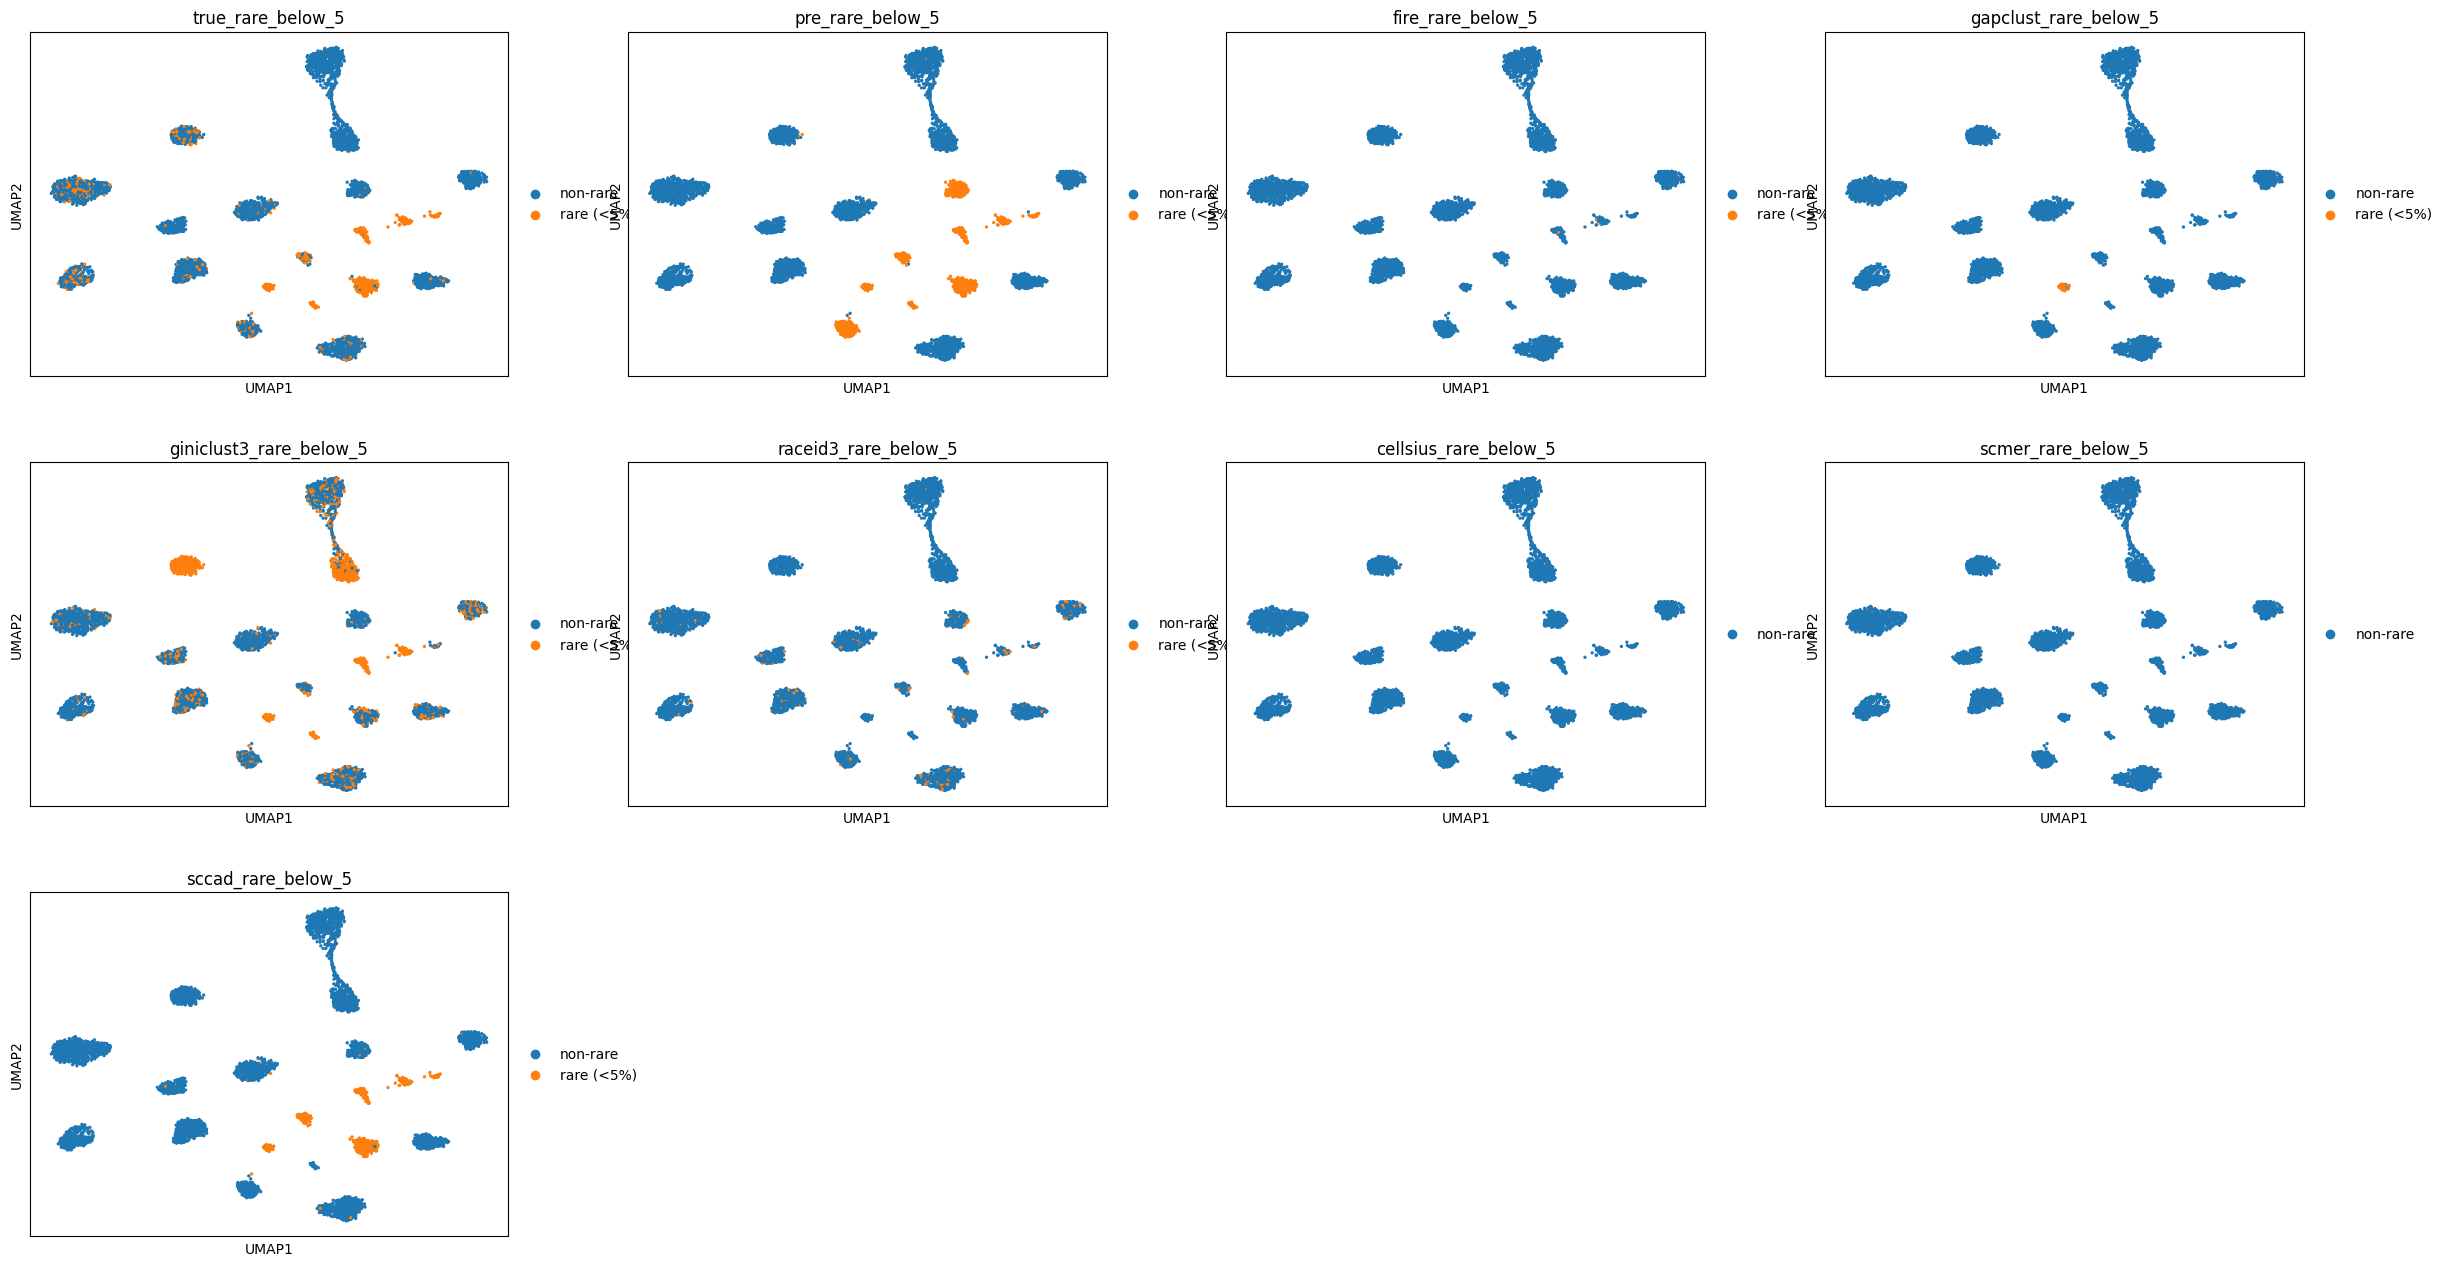

In [15]:
# 获取真实标签中小于 5% 的稀有细胞类型
cell_types = adata.obs['Annotation']
cell_type_counts = cell_types.value_counts()
cell_type_proportions = cell_type_counts / cell_type_counts.sum()

# 定义小于5%的稀有细胞类型
target_cell_types_below_5 = cell_type_proportions[cell_type_proportions < 0.045].index.tolist()

# 标记真实标签中小于5%的细胞
adata.obs['true_rare_below_5'] = adata.obs['Annotation'].apply(
    lambda x: 'rare (<5%)' if x in target_cell_types_below_5 else 'non-rare'
)

# 映射 `pre` 的结果
if 'pre' in adata.obs.columns:
    pre_labels = adata.obs['pre']
    cluster_counts = pre_labels.value_counts(normalize=True)

    # 定义小于5%的稀有簇
    rare_clusters_below_5 = cluster_counts[cluster_counts < 0.045].index.tolist()

    # 映射到 `rare` 和 `non-rare`
    adata.obs['pre_rare_below_5'] = adata.obs['pre'].apply(
        lambda x: 'rare (<5%)' if x in rare_clusters_below_5 else 'non-rare'
    )
else:
    raise ValueError("'pre' 列未在 adata.obs 中找到！")

# 对比模型和 `pre` 的预测结果
models = ['fire', 'gapclust', 'giniclust3', 'raceid3', 'cellsius', 'scmer', 'sccad']

# 处理每个模型的预测结果
for model in models:
    if model not in adata.obs.columns:
        print(f"Model {model} not found in adata.obs, skipping...")
        continue

    # 映射模型的预测结果到稀有细胞类别
    adata.obs[f'{model}_rare_below_5'] = adata.obs[model].map(
        {'rare': 'rare (<5%)', 'non-rare': 'non-rare'}
    ).fillna('non-rare')  # 若存在 NaN，默认为 non-rare

# 确保绘图的列存在于 adata.obs
umap_colors = ['true_rare_below_5', 'pre_rare_below_5'] + [
    f'{model}_rare_below_5' for model in models if f'{model}_rare_below_5' in adata.obs
]

# UMAP 可视化
sc.pl.umap(adata, color=umap_colors, show=True)


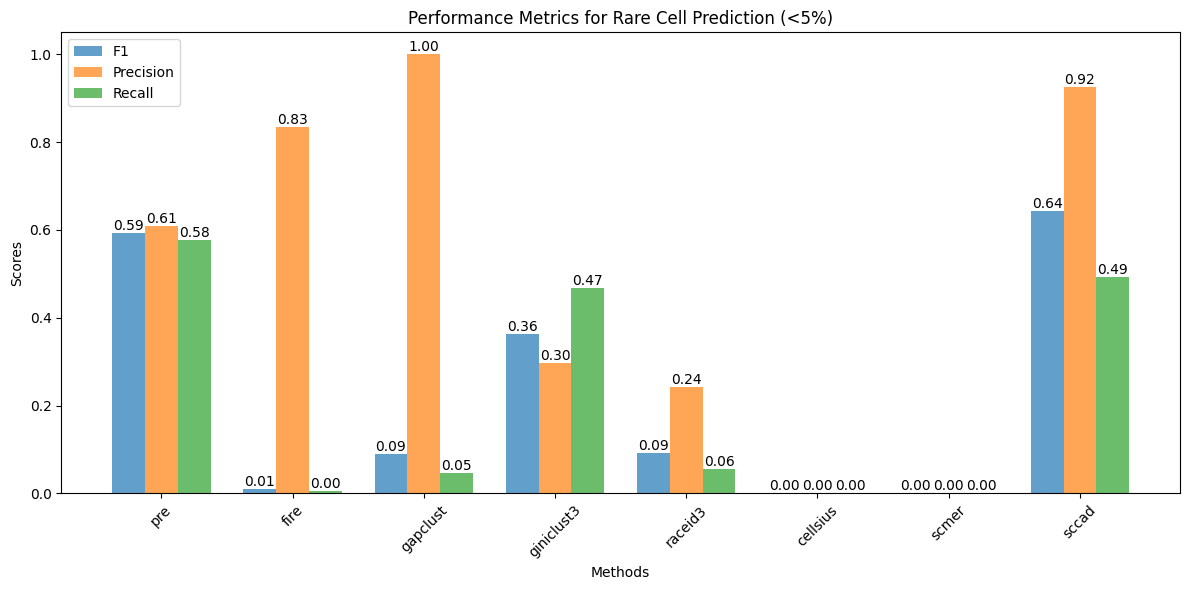

In [18]:
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

# 初始化存储结果的字典
results = {}

# 提取真实标签
true_labels = adata.obs['true_rare_below_5'].map({'rare (<5%)': 1, 'non-rare': 0})

# 计算 `pre` 的指标
if 'pre_rare_below_5' in adata.obs.columns:
    pre_predicted_labels = adata.obs['pre_rare_below_5'].map({'rare (<5%)': 1, 'non-rare': 0})
    f1_pre = f1_score(true_labels, pre_predicted_labels)
    precision_pre = precision_score(true_labels, pre_predicted_labels)
    recall_pre = recall_score(true_labels, pre_predicted_labels)
    results['pre'] = {'F1': f1_pre, 'Precision': precision_pre, 'Recall': recall_pre}

# 计算其他模型的指标
models = ['fire', 'gapclust', 'giniclust3', 'raceid3', 'cellsius', 'scmer', 'sccad']
for model in models:
    if f'{model}_rare_below_5' in adata.obs.columns:
        predicted_labels = adata.obs[f'{model}_rare_below_5'].map({'rare (<5%)': 1, 'non-rare': 0})
        f1 = f1_score(true_labels, predicted_labels)
        precision = precision_score(true_labels, predicted_labels)
        recall = recall_score(true_labels, predicted_labels)
        results[model] = {'F1': f1, 'Precision': precision, 'Recall': recall}

# 准备数据用于绘图
methods = list(results.keys())
f1_scores = [results[method]['F1'] for method in methods]
precision_scores = [results[method]['Precision'] for method in methods]
recall_scores = [results[method]['Recall'] for method in methods]

# 绘制柱状图并显示具体数值
x = range(len(methods))
bar_width = 0.25

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x, f1_scores, width=bar_width, label='F1', alpha=0.7)
bars2 = plt.bar([p + bar_width for p in x], precision_scores, width=bar_width, label='Precision', alpha=0.7)
bars3 = plt.bar([p + 2 * bar_width for p in x], recall_scores, width=bar_width, label='Recall', alpha=0.7)

# 添加数值显示
for bar in bars1:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.2f}', ha='center', va='bottom')
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.2f}', ha='center', va='bottom')
for bar in bars3:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.2f}', ha='center', va='bottom')

plt.xticks([p + bar_width for p in x], methods, rotation=45)
plt.xlabel('Methods')
plt.ylabel('Scores')
plt.title('Performance Metrics for Rare Cell Prediction (<5%)')
plt.legend()
plt.tight_layout()

# 保存图表并显示
plt.savefig('figures/metrics.pdf', format='pdf', bbox_inches='tight')
plt.show()


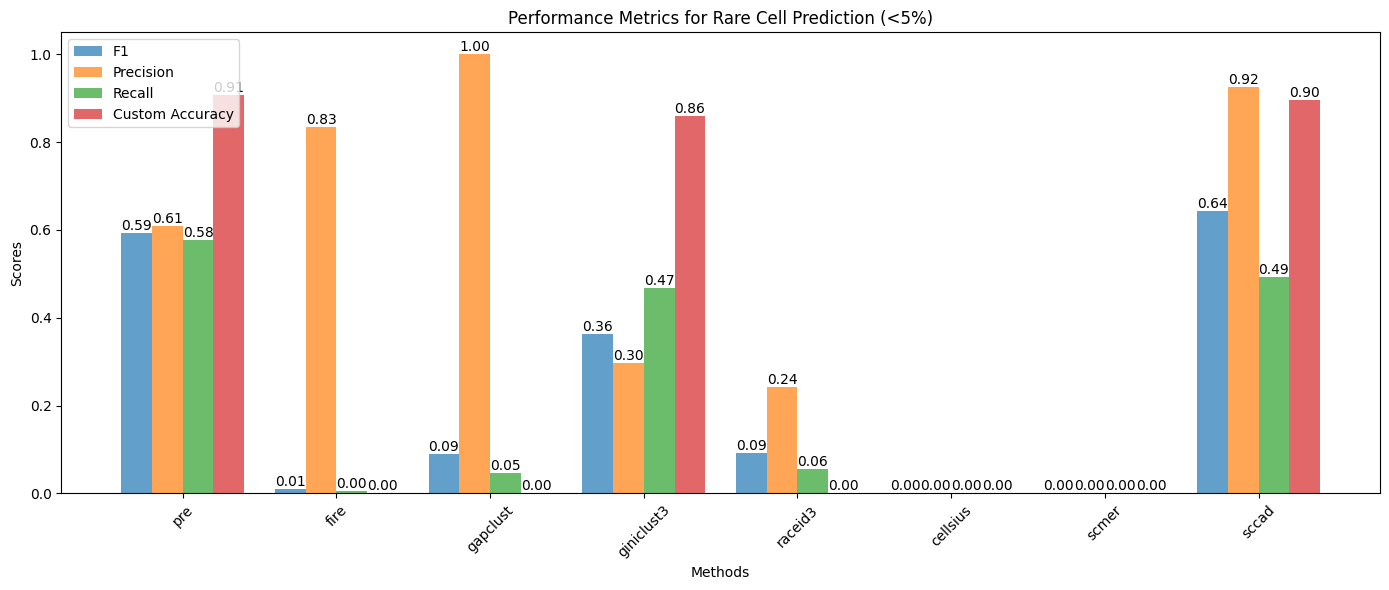

In [19]:
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

# 初始化存储结果的字典
results = {}

# 提取真实标签
true_labels = adata.obs['true_rare_below_5'].map({'rare (<5%)': 1, 'non-rare': 0})

# 自定义准确率函数
# 自定义准确率函数（增加限制）
def custom_accuracy(y_true, y_pred, min_rare_predictions=5, rare_detection_threshold=0.1):
    """
    计算自定义准确率，同时增加限制：
    - 预测中必须包含至少 min_rare_predictions 个稀有标签。
    - 稀有预测中，必须正确预测至少 rare_detection_threshold * 真实稀有标签数 的稀有样本。
    """
    # 判断稀有预测是否足够
    rare_predictions = sum(y_pred)  # 预测为稀有的数量
    true_rare_count = sum(y_true)  # 真实稀有的数量
    if rare_predictions < min_rare_predictions:  # 限制稀有预测数量
        return 0

    # 判断正确预测的稀有标签是否足够
    correct_rare_predictions = sum((y_pred == 1) & (y_true == 1))
    if correct_rare_predictions < rare_detection_threshold * true_rare_count:  # 限制稀有检测能力
        return 0

    # 按照自定义逻辑计算准确率
    correct = 0
    total = 0
    for true, pred in zip(y_true, y_pred):
        if pred == 1 and true == 1:  # 预测为稀有，且真实也是稀有
            correct += 1
            total += 1
        elif pred == 0 and true == 0:  # 预测为非稀有，且真实也是非稀有
            correct += 1
            total += 1
        elif pred == 0 and true == 1:  # 预测为非稀有，但真实为稀有
            total += 1  # 错误预测计入分母
        # 对于预测为稀有但真实为非稀有（pred == 1 and true == 0），不计入
    return correct / total if total > 0 else 0  # 避免除零


# 计算 `pre` 的指标
if 'pre_rare_below_5' in adata.obs.columns:
    pre_predicted_labels = adata.obs['pre_rare_below_5'].map({'rare (<5%)': 1, 'non-rare': 0})
    f1_pre = f1_score(true_labels, pre_predicted_labels)
    precision_pre = precision_score(true_labels, pre_predicted_labels)
    recall_pre = recall_score(true_labels, pre_predicted_labels)
    accuracy_pre = custom_accuracy(true_labels, pre_predicted_labels)
    results['pre'] = {'F1': f1_pre, 'Precision': precision_pre, 'Recall': recall_pre, 'Custom Accuracy': accuracy_pre}

# 计算其他模型的指标
models = ['fire', 'gapclust', 'giniclust3', 'raceid3', 'cellsius', 'scmer', 'sccad']
for model in models:
    if f'{model}_rare_below_5' in adata.obs.columns:
        predicted_labels = adata.obs[f'{model}_rare_below_5'].map({'rare (<5%)': 1, 'non-rare': 0})
        f1 = f1_score(true_labels, predicted_labels)
        precision = precision_score(true_labels, predicted_labels)
        recall = recall_score(true_labels, predicted_labels)
        accuracy = custom_accuracy(true_labels, predicted_labels)
        results[model] = {'F1': f1, 'Precision': precision, 'Recall': recall, 'Custom Accuracy': accuracy}

# 准备数据用于绘图
methods = list(results.keys())
f1_scores = [results[method]['F1'] for method in methods]
precision_scores = [results[method]['Precision'] for method in methods]
recall_scores = [results[method]['Recall'] for method in methods]
accuracy_scores = [results[method]['Custom Accuracy'] for method in methods]

# 绘制柱状图并显示具体数值
x = range(len(methods))
bar_width = 0.2

plt.figure(figsize=(14, 6))

bars1 = plt.bar(x, f1_scores, width=bar_width, label='F1', alpha=0.7)
bars2 = plt.bar([p + bar_width for p in x], precision_scores, width=bar_width, label='Precision', alpha=0.7)
bars3 = plt.bar([p + 2 * bar_width for p in x], recall_scores, width=bar_width, label='Recall', alpha=0.7)
bars4 = plt.bar([p + 3 * bar_width for p in x], accuracy_scores, width=bar_width, label='Custom Accuracy', alpha=0.7)

# 添加数值显示
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.2f}', ha='center', va='bottom')

plt.xticks([p + 1.5 * bar_width for p in x], methods, rotation=45)
plt.xlabel('Methods')
plt.ylabel('Scores')
plt.title('Performance Metrics for Rare Cell Prediction (<5%)')
plt.legend()
plt.tight_layout()

# 保存图表并显示
plt.savefig('figures/metrics_custom_accuracy.pdf', format='pdf', bbox_inches='tight')
plt.show()

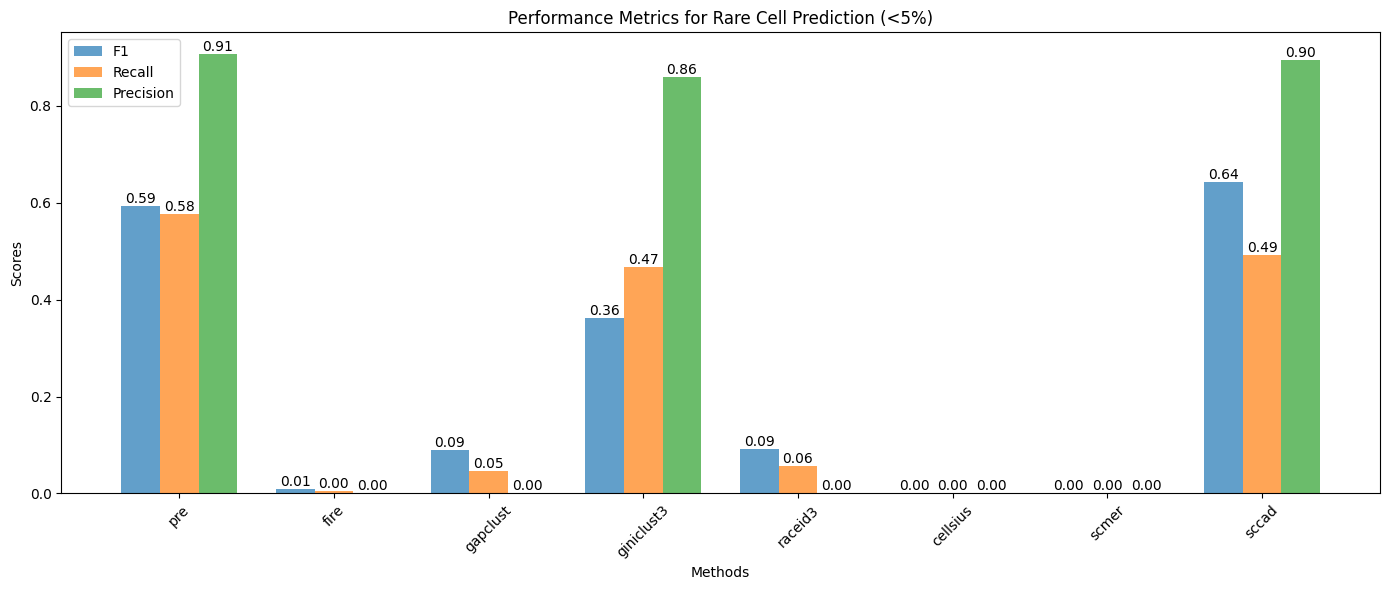

In [21]:
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

# 初始化存储结果的字典
results = {}

# 提取真实标签
true_labels = adata.obs['true_rare_below_5'].map({'rare (<5%)': 1, 'non-rare': 0})

# 自定义准确率函数（不变）
# def custom_accuracy(y_true, y_pred, min_rare_predictions=5, rare_detection_threshold=0.1):
#     rare_predictions = sum(y_pred)
#     true_rare_count = sum(y_true)
#     if rare_predictions < min_rare_predictions:
#         return 0
#     correct_rare_predictions = sum((y_pred == 1) & (y_true == 1))
#     if correct_rare_predictions < rare_detection_threshold * true_rare_count:
#         return 0
#     correct = 0
#     total = 0
#     for true, pred in zip(y_true, y_pred):
#         if pred == 1 and true == 1:
#             correct += 1
#             total += 1
#         elif pred == 0 and true == 0:
#             correct += 1
#             total += 1
#         elif pred == 0 and true == 1:
#             total += 1
#     return correct / total if total > 0 else 0

# 计算 `pre` 的指标
if 'pre_rare_below_5' in adata.obs.columns:
    pre_predicted_labels = adata.obs['pre_rare_below_5'].map({'rare (<5%)': 1, 'non-rare': 0})
    f1_pre = f1_score(true_labels, pre_predicted_labels)
    precision_pre = custom_accuracy(true_labels, pre_predicted_labels)
    recall_pre = recall_score(true_labels, pre_predicted_labels)
    results['pre'] = {'F1': f1_pre, 'Precision': precision_pre, 'Recall': recall_pre}

# 计算其他模型的指标
models = ['fire', 'gapclust', 'giniclust3', 'raceid3', 'cellsius', 'scmer', 'sccad']
for model in models:
    if f'{model}_rare_below_5' in adata.obs.columns:
        predicted_labels = adata.obs[f'{model}_rare_below_5'].map({'rare (<5%)': 1, 'non-rare': 0})
        f1 = f1_score(true_labels, predicted_labels)
        precision = custom_accuracy(true_labels, predicted_labels)
        recall = recall_score(true_labels, predicted_labels)
        results[model] = {'F1': f1, 'Precision': precision, 'Recall': recall}

# 准备数据用于绘图
methods = list(results.keys())
f1_scores = [results[method]['F1'] for method in methods]
recall_scores = [results[method]['Recall'] for method in methods]
precision_scores = [results[method]['Precision'] for method in methods]

# 绘制柱状图并显示具体数值
x = range(len(methods))
bar_width = 0.25

plt.figure(figsize=(14, 6))

bars1 = plt.bar(x, f1_scores, width=bar_width, label='F1', alpha=0.7)
bars2 = plt.bar([p + bar_width for p in x], recall_scores, width=bar_width, label='Recall', alpha=0.7)
bars3 = plt.bar([p + 2 * bar_width for p in x], precision_scores, width=bar_width, label='Precision', alpha=0.7)

# 添加数值显示
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{bar.get_height():.2f}', ha='center', va='bottom')

plt.xticks([p + bar_width for p in x], methods, rotation=45)
plt.xlabel('Methods')
plt.ylabel('Scores')
plt.title('Performance Metrics for Rare Cell Prediction (<5%)')
plt.legend()
plt.tight_layout()

# 保存图表并显示
plt.savefig('figures/metrics_precision.pdf', format='pdf', bbox_inches='tight')
plt.show()
